In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [2]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

In [3]:
X

array([[-8.55503989,  7.06461794],
       [-6.13753182, -6.58081701],
       [-6.32130028, -6.8041042 ],
       ...,
       [ 3.69047995,  4.60555175],
       [-7.48913939, -7.0670809 ],
       [-9.40049578,  7.11430104]], shape=(1000, 2))

<Axes: >

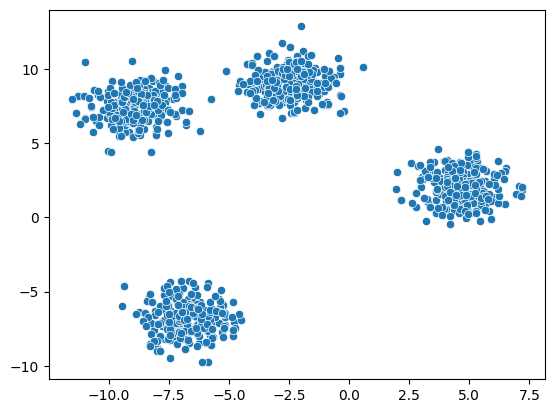

In [4]:
#Visualize
sns.scatterplot(x=X[:,0], y=X[:, 1])

In [5]:
# K-Means Clustering
from sklearn.cluster import KMeans

In [6]:
K = 4
kmeans = KMeans(
    n_clusters = K,
    random_state=42
)

In [7]:
labels = kmeans.fit_predict(X)

<Axes: >

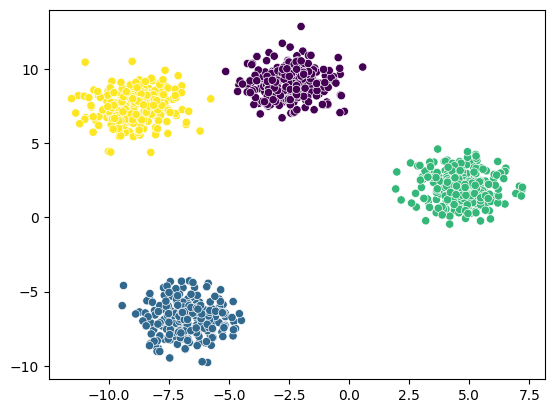

In [8]:
sns.scatterplot(x=X[:, 0], y=X[:,1], c=labels)

## Choose our K value-elbow; silhouette score

In [9]:
# elbow
wcss = []
for k in range(1, 21) :
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

<Axes: >

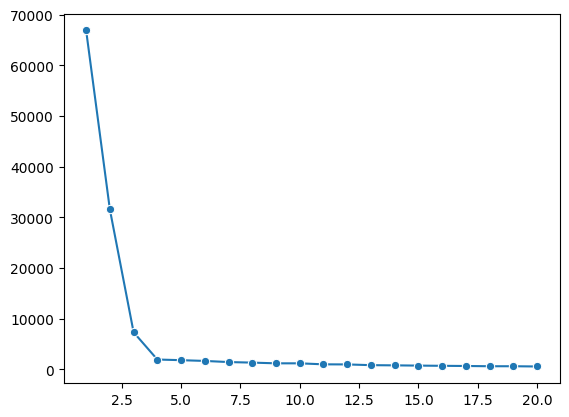

In [10]:
sns.lineplot(x=range(1,21), y=wcss, marker="o")

In [11]:
# kneed Module

In [12]:
from kneed import KneeLocator

In [13]:
knee = KneeLocator(range(1, 21), wcss, curve="convex", direction="decreasing")

In [14]:
print(knee.elbow)

4


## Silhouette Score

In [15]:
from sklearn.metrics import silhouette_score

In [16]:
ss = []
for k in range(2,21) :
    kmeans = KMeans(n_clusters = k) 
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    ss.append(score)

<Axes: >

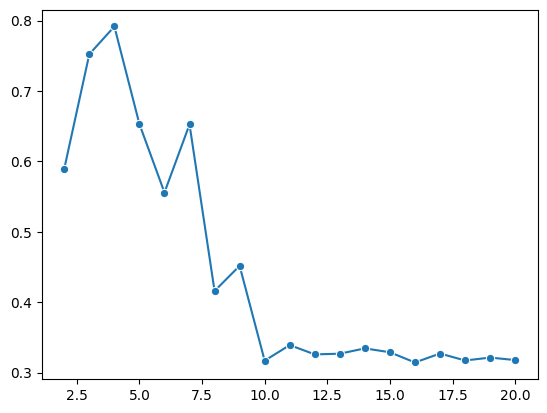

In [17]:
# plot - K & ss
sns.lineplot(x=range(2,21), y=ss, marker = "o")

### K-Means_for_Iris

In [18]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [19]:
iris = load_iris()

In [20]:
X = pd.DataFrame(iris.data)
y = iris.target

In [21]:
X.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [22]:
X.columns = iris.feature_names

In [23]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

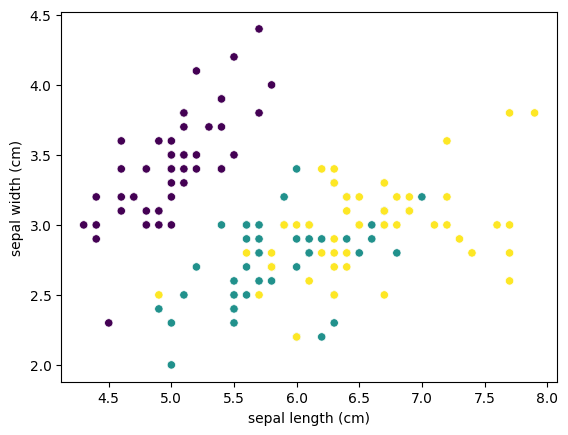

In [24]:
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], c = y)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
# PCA
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

pca_data = pca.fit_transform(X_scaled)

In [27]:
# Elbow Method
wcss = []
for k in range(1,11) :
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

<Axes: >

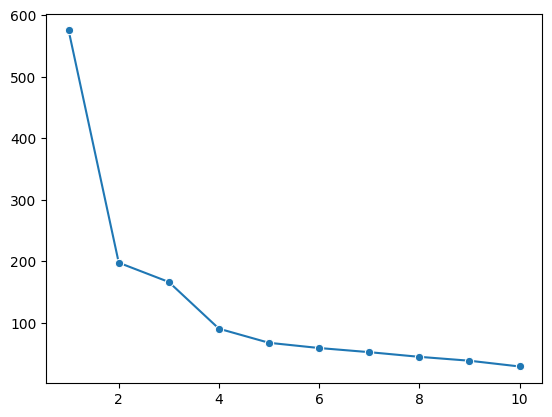

In [28]:
sns.lineplot(x=range(1,11), y=wcss, marker = "o")

In [29]:
# K-Means

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(pca_data)

#sns.scatterplot(x=X[:,0], y=X[:,1])

<Axes: >

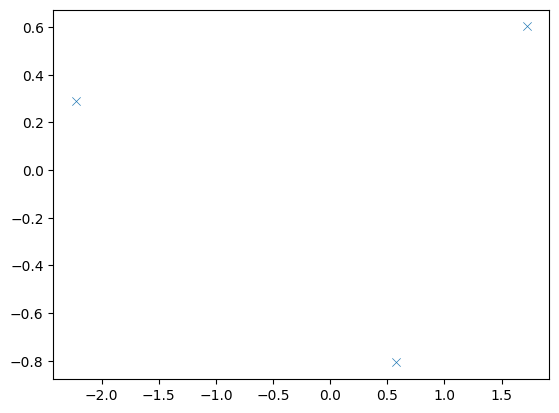

In [30]:
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1], marker="x")

## Hierarchical_clustering

In [31]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [32]:
iris = load_iris()

X = iris.data
y = iris.target



In [34]:
# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<Axes: >

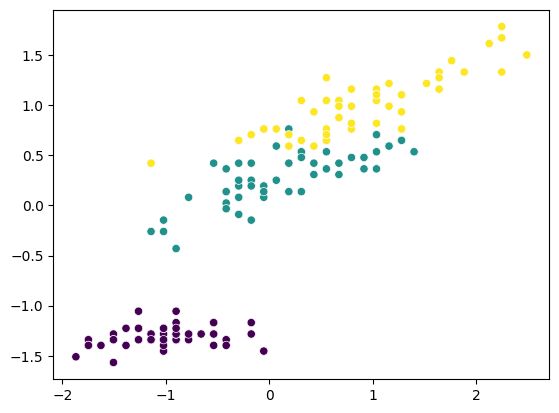

In [36]:
# visualize
sns.scatterplot(x=X_scaled[:, 0], y= X_scaled[:,2], c=y)

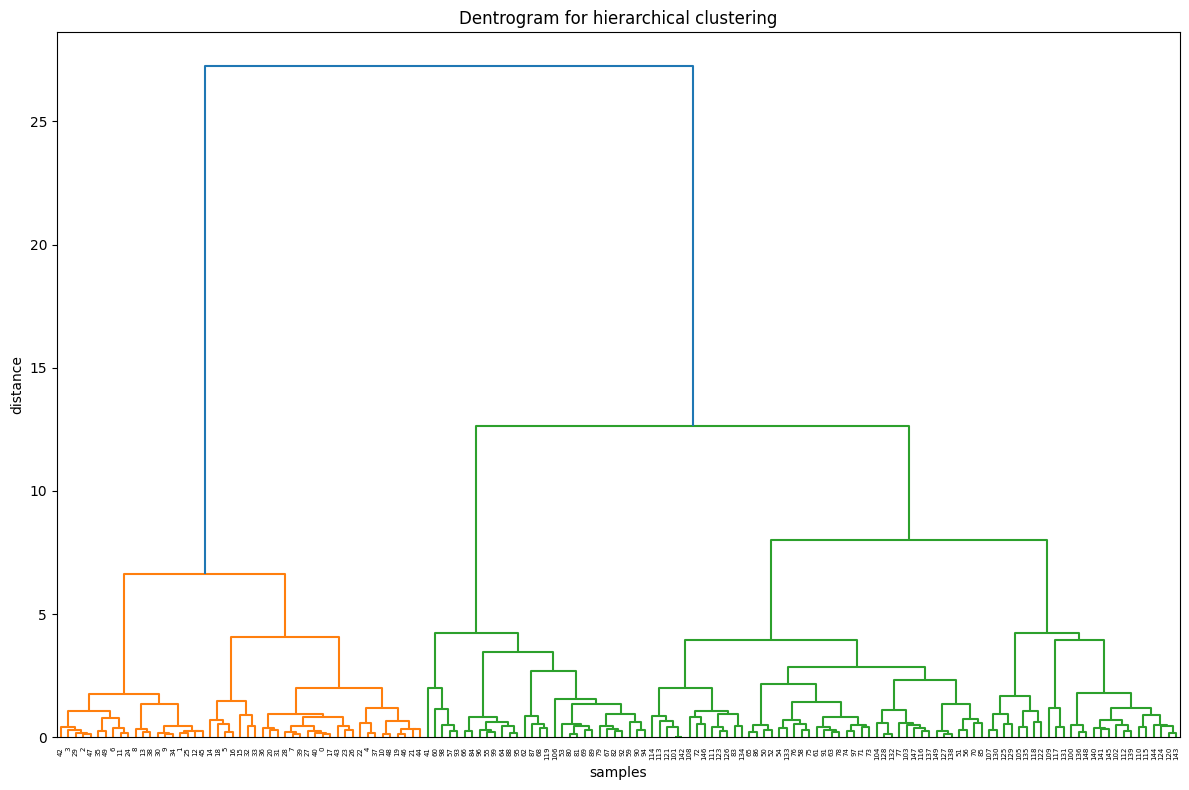

In [39]:
from scipy.cluster.hierarchy import linkage, dendrogram

# linkage matrix
Z = linkage(X_scaled, method = "ward")

# plot
plt.figure(figsize=(12,8))
dendrogram(Z)
plt.xlabel("samples")
plt.ylabel("distance")
plt.title("Dentrogram for hierarchical clustering")
plt.tight_layout()

In [40]:
# Clustering
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters = 2)
labels = agg.fit_predict(X_scaled)

## DBSCAN

In [41]:
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [42]:
iris = load_iris()

X = iris.data
y = iris.target

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<Axes: >

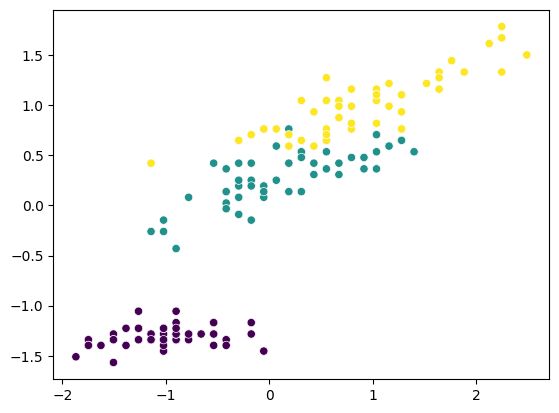

In [46]:
# visualization
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,2], c=y)

In [47]:
# DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps = 0.8,
    min_samples = 5
)

In [48]:
labels = dbscan.fit_predict(X_scaled)

<Axes: >

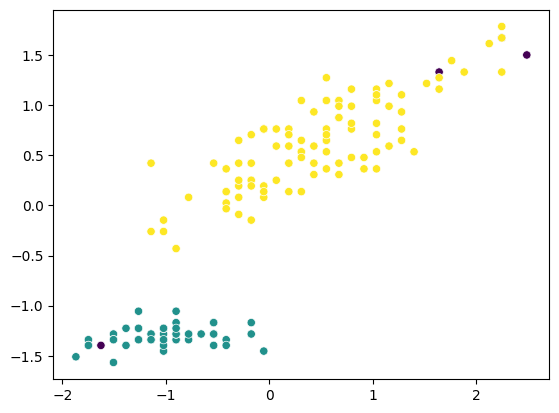

In [50]:
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,2], c=labels)

## Non-Linear Data

In [51]:
from sklearn.datasets import make_moons

In [54]:
X, y = make_moons(
    n_samples = 300,
    noise = 0.05,
    random_state = 42
)

In [55]:
X

array([[ 6.22519125e-01, -3.72101344e-01],
       [ 1.90426932e+00, -1.36302945e-01],
       [-6.94312816e-02,  4.56116985e-01],
       [ 9.33898633e-01,  2.37482827e-01],
       [ 1.18035952e+00, -4.90846917e-01],
       [ 1.02541488e+00, -4.62482874e-01],
       [ 4.11984697e-01, -2.85969715e-01],
       [-6.12663134e-01,  7.29788185e-01],
       [ 9.48145854e-01,  7.95791386e-02],
       [ 1.71242445e-01,  1.58374951e-03],
       [ 1.29201956e+00, -3.77322706e-01],
       [ 3.72211026e-01,  8.92249223e-01],
       [ 9.16250451e-01, -4.88055386e-01],
       [ 6.26278567e-01,  8.66028662e-01],
       [ 1.71157998e-01, -5.55663311e-02],
       [ 9.71527259e-01, -5.27473544e-01],
       [ 1.99307684e+00,  3.03573972e-01],
       [ 7.20383729e-01, -4.16166842e-01],
       [-9.27909913e-01,  2.14482709e-02],
       [ 1.16141211e-01,  2.38388568e-01],
       [-6.21140311e-02,  1.00608737e+00],
       [-7.83123575e-01,  6.13188694e-01],
       [ 1.50215227e+00, -4.12314518e-01],
       [ 1.

<Axes: >

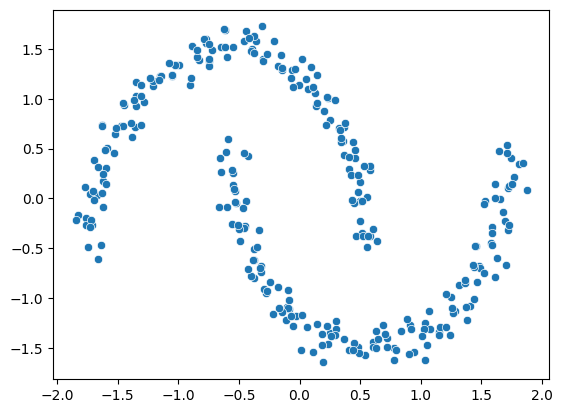

In [58]:
X_scaled = scaler.fit_transform(X)

sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1])

In [59]:
# K-Means
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters = 2,
    random_state = 42
)

labels = kmeans.fit_predict(X_scaled)

<Axes: >

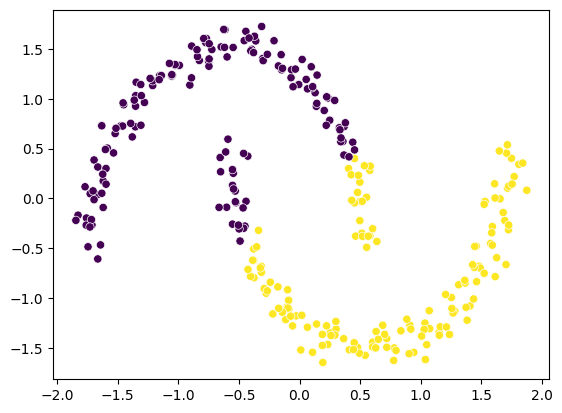

In [60]:
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], c=labels)

In [61]:
# DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps = 0.8,
    min_samples = 5
)

labels = dbscan.fit_predict(X_scaled)

<Axes: >

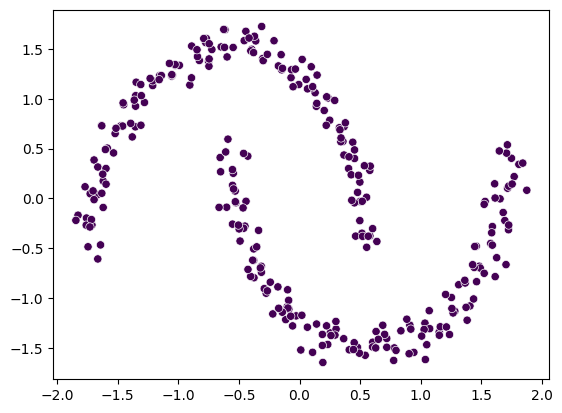

In [62]:
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], c=labels)